# ■ 딥러닝 컴페티션

### 컴페티션의 목표는 ① 학습 평가의 이해, ② 딥러닝 성능 개선 방법 숙지, ③ 설명력을 키우는게 목적

## ■ 공지

※ 모델 성능이 제일 높은 기준으로 채점 X (상대평가는 안하지만, 개인 성능은 valid score가 75이상 나오길 권장함.)

※ 수업 코드 사용 가능

※ 학습자 간 상의 절대 금지.

※ 최신 기술 또는 대단한 아이디어 보다. ① 코딩의 인과성, ② 설명의 깊이만 충분하다면, 만점이 가능합니다.

</br>

## ■ 평가기준 (총점 90점) ※ 글자 수로 점수 평가 X

1. (15점) 전처리 아이디어 적합성 + 논리 (650자 이내, 주석 서술하기)

2. (20점) EDA를 통한 타당한 해석 (650자 이내, 주석 서술하기)

3. (25점) Feature Selection과 모델 선택, 튜닝 기준 (650자 이내, 주석 서술하기)

4. (25점) 개선사항 (650자 이내, 주석 서술하기)

5. (5점 ) validation score 적절하게 출력 (300자 이내, 주석 서술하기)

</br>

## ■ 깃허브 정리 (10점)

1. 포트폴리오로 쓸 수 있도록 프로젝트 제목, 전처리, EDA, 모델링 방법, 성능 결과를 캡처 이미지와 함께 잘 정리.

</br>

## ■ 제출방법

5월 12일 23시 59분까지, 오승환 강사에게 DM으로 ipynb 파일 제출, 이후 깃허브 링크도 정리되는대로 DM 제출

# 1. 원본 데이터 출처

https://www.kaggle.com/datasets/parisrohan/credit-score-classification

# 2. 데이터 클리닝 방법 출처:

https://www.kaggle.com/code/clkmuhammed/credit-score-classification-part-1-data-cleaning#Download-Link

In [1]:
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# import pandas as pd
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, LabelEncoder

# file_path = 'train2.csv'
# data = pd.read_csv(file_path)

# data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN'])

# categorical_columns = ['Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']

# for col in categorical_columns:
#     le = LabelEncoder()
#     data[col] = le.fit_transform(data[col])

# target_encoder = LabelEncoder()
# data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

# X = data.drop('Credit_Score', axis=1).values
# y = data['Credit_Score'].values

# scaler = StandardScaler()
# X = scaler.fit_transform(X)


# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# class CreditScoreDataset(Dataset):
#     def __init__(self, X, y):
#         self.X = torch.tensor(X, dtype=torch.float32)
#         self.y = torch.tensor(y, dtype=torch.long)

#     def __len__(self):
#         return len(self.y)

#     def __getitem__(self, idx):
#         return self.X[idx], self.y[idx]


# train_dataset = CreditScoreDataset(X_train, y_train)
# test_dataset = CreditScoreDataset(X_test, y_test)

# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
# test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# class MLP(nn.Module):
#     def __init__(self, input_size):
#         super(MLP, self).__init__()
#         self.layer1 = nn.Linear(input_size, 64)
#         self.layer2 = nn.Linear(64, 32)
#         self.layer3 = nn.Linear(32, 3)
#         self.relu = nn.ReLU()

#     def forward(self, x):
#         x = self.relu(self.layer1(x))
#         x = self.relu(self.layer2(x))
#         x = self.layer3(x)
#         return x

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# input_size = X_train.shape[1]
# model = MLP(input_size).to(device)

# criterion = nn.CrossEntropyLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)

# epochs = 20

# for epoch in range(epochs):
#     model.train()
#     running_loss = 0.0
#     correct_train = 0
#     total_train = 0

#     for inputs, targets in train_loader:
#         inputs, targets = inputs.to(device), targets.to(device)
#         optimizer.zero_grad()
#         outputs = model(inputs)
#         loss = criterion(outputs, targets)
#         loss.backward()
#         optimizer.step()
#         running_loss += loss.item()

#         _, predicted = torch.max(outputs, 1)
#         total_train += targets.size(0)
#         correct_train += (predicted == targets).sum().item()

#     model.eval()
#     correct_val = 0
#     total_val = 0
#     with torch.no_grad():
#         for inputs, targets in test_loader:
#             inputs, targets = inputs.to(device), targets.to(device)
#             outputs = model(inputs)
#             _, predicted = torch.max(outputs, 1)
#             total_val += targets.size(0)
#             correct_val += (predicted == targets).sum().item()

#     train_accuracy = 100 * correct_train / total_train
#     val_accuracy = 100 * correct_val / total_val
#     print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(train_loader):.4f}, '
#           f'학습 정확도: {train_accuracy:.2f}%, 평가 정확도: {val_accuracy:.2f}%')


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [3]:
file_path = 'train2.csv'
data = pd.read_csv(file_path)

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
data.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,5634,3392,1,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,26.822620,265,No,49.574949,21.46538,High_spent_Small_value_payments,312.494089,Good
1,5635,3392,2,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.944960,266,No,49.574949,21.46538,Low_spent_Large_value_payments,284.629163,Good
2,5636,3392,3,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,28.609352,267,No,49.574949,21.46538,Low_spent_Medium_value_payments,331.209863,Good
3,5637,3392,4,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,31.377862,268,No,49.574949,21.46538,Low_spent_Small_value_payments,223.451310,Good
4,5638,3392,5,Aaron Maashoh,23,821000265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,269,No,49.574949,21.46538,High_spent_Medium_value_payments,341.489231,Good


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  int64  
 1   Customer_ID               100000 non-null  int64  
 2   Month                     100000 non-null  int64  
 3   Name                      100000 non-null  object 
 4   Age                       100000 non-null  int64  
 5   SSN                       100000 non-null  int64  
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  float64
 8   Monthly_Inhand_Salary     100000 non-null  float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  int64  
 13  Type_of_Loan              100000 non-null  ob

/tmp/ipykernel_4400/2686478652.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Credit_Score', order=data['Credit_Score'].value_counts().index, palette='viridis')


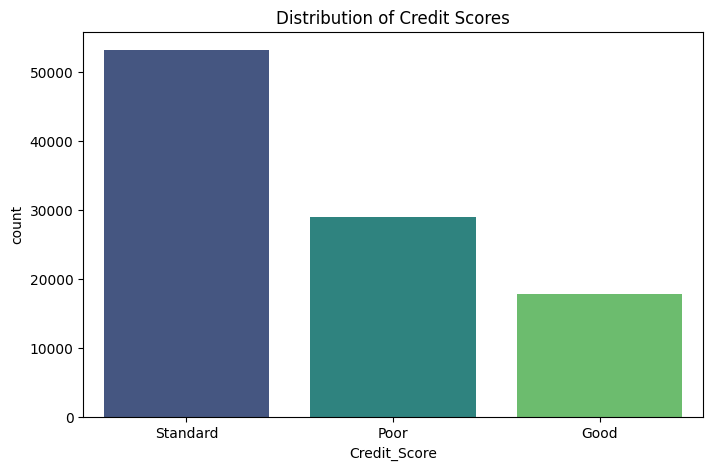

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Credit_Score 분포확인
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='Credit_Score', order=data['Credit_Score'].value_counts().index, palette='viridis')
plt.title('Distribution of Credit Scores')
plt.show()

In [8]:
# Standard, Poor, Good 순으로 분포되어있음.
# 클래스 편향을 주의해서 모델을 학습하고 확인한다.

/tmp/ipykernel_4400/3367321928.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Credit_Score', y='Outstanding_Debt', ax=axes[0], palette='Set2')
/tmp/ipykernel_4400/3367321928.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='Credit_Score', y='Interest_Rate', ax=axes[1], palette='Set2')


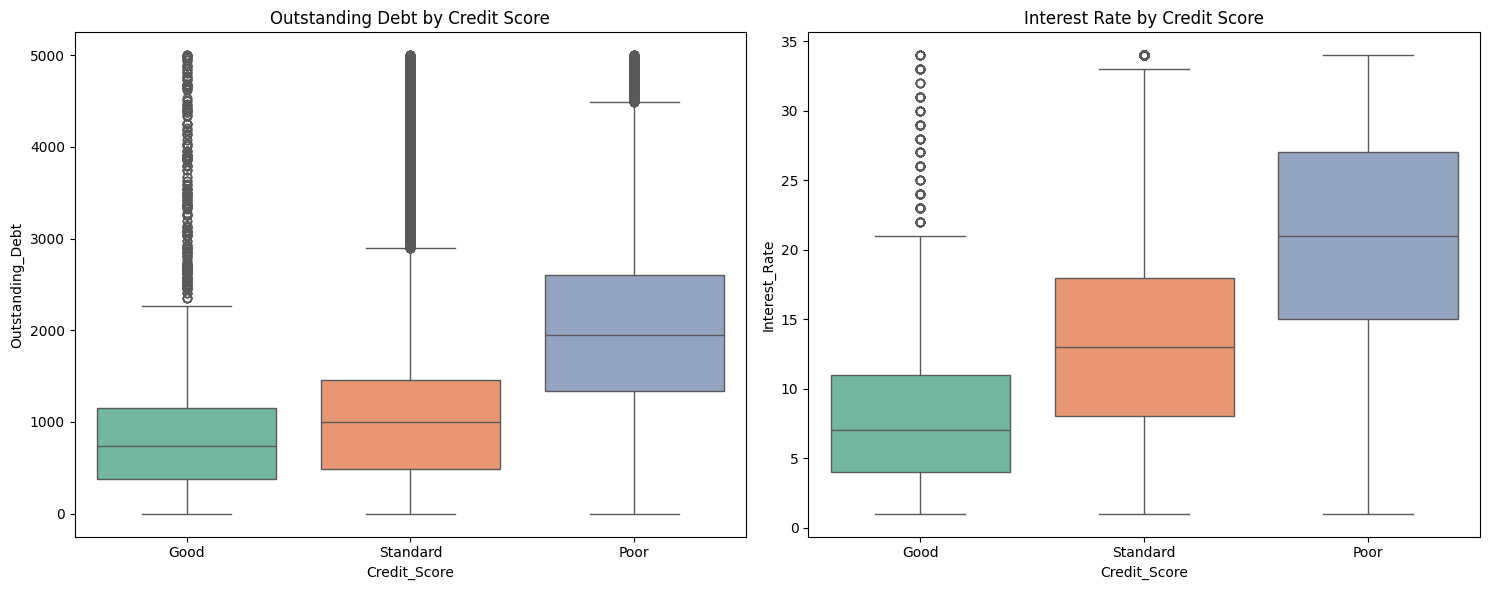

In [9]:
# 미지급 잔액과 신용카드 이자율에 따른 신용점수 분포
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=data, x='Credit_Score', y='Outstanding_Debt', ax=axes[0], palette='Set2')
axes[0].set_title('Outstanding Debt by Credit Score')

sns.boxplot(data=data, x='Credit_Score', y='Interest_Rate', ax=axes[1], palette='Set2')
axes[1].set_title('Interest Rate by Credit Score')

plt.tight_layout()
plt.show()

In [10]:
# 신용점수가 높을수록 미지급 금액의 중앙값이 낮아지는 것으로 확인
# 신용카드 이자율도 신용점수가 높을수록 중앙값이 낮아지는 것으로 확인되었으나 'Good'등급에 이상치가 다분포되어있는 것으로 확인.
# 위의 그래프를 보았을 때 미지급 금액과 신용카드 이자율에 따라 신용등급의 변화가 있을 것으로 추

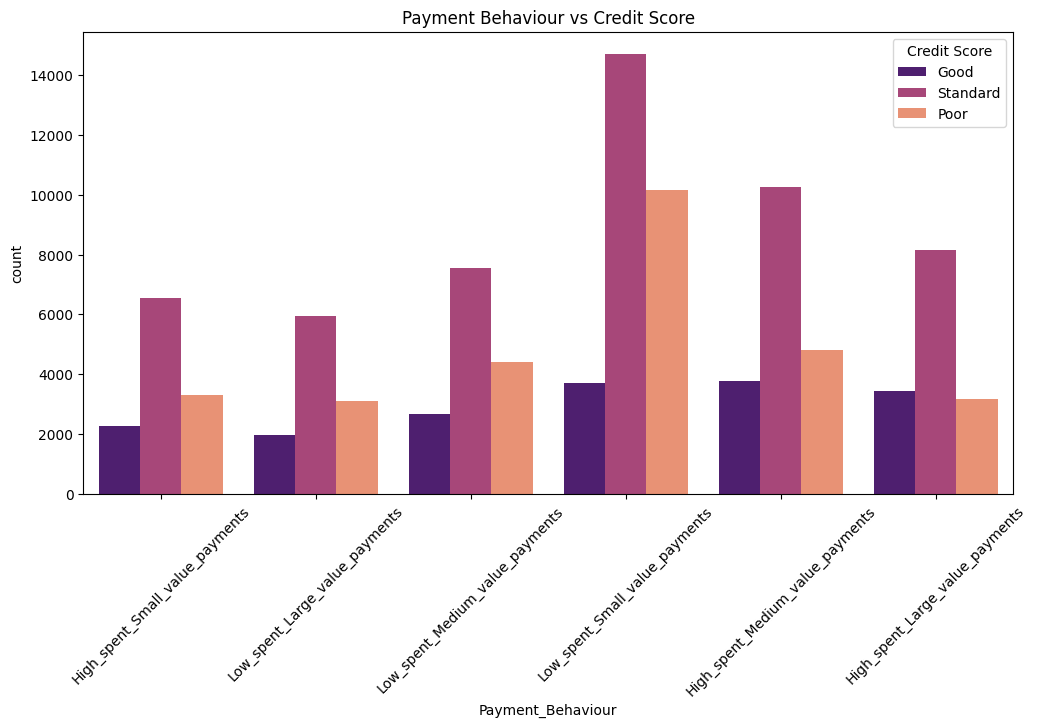

In [11]:
# 고객납부행태별 신용등급 분포
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Payment_Behaviour', hue='Credit_Score', palette='magma')
plt.xticks(rotation=45)
plt.title('Payment Behaviour vs Credit Score')
plt.legend(title='Credit Score', loc='upper right')
plt.show()

In [12]:
# 저지출 소액결제 패턴에 모든 신용등급을 포함해 대다수의 고객이 몰려있는 것으로 확인돠었다.
# Good 등급에서는 다른 등급에 비해 큰 변동이 보이지 않는다. 소비패턴이 Good등급이 되는 지표가 아닐 것이라는 추론

In [13]:
len(data['Type_of_Loan'].unique())
data['Type_of_Loan'].unique()
# 'Type_of_Loan'의 유니크한 범주형 값이 6000개가 넘고 콤마로 다수의 대출종류가 나열 되어있음. 복잡도 대비 정보 중요도가 낮다고 판단하여
# 'Num_of_Loan' 컬럼으로 정보를 대체해서 'Type_of_Loan'컬럼을 제외하는 것으로 결정

array(['auto loan,credit-builder loan,personal loan,home equity loan',
       'credit-builder loan', 'auto loan,auto loan,not specified', ...,
       'home equity loan,auto loan,auto loan,auto loan',
       'payday loan,student loan,mortgage loan,not specified',
       'personal loan,auto loan,mortgage loan,student loan,student loan'],
      dtype=object)

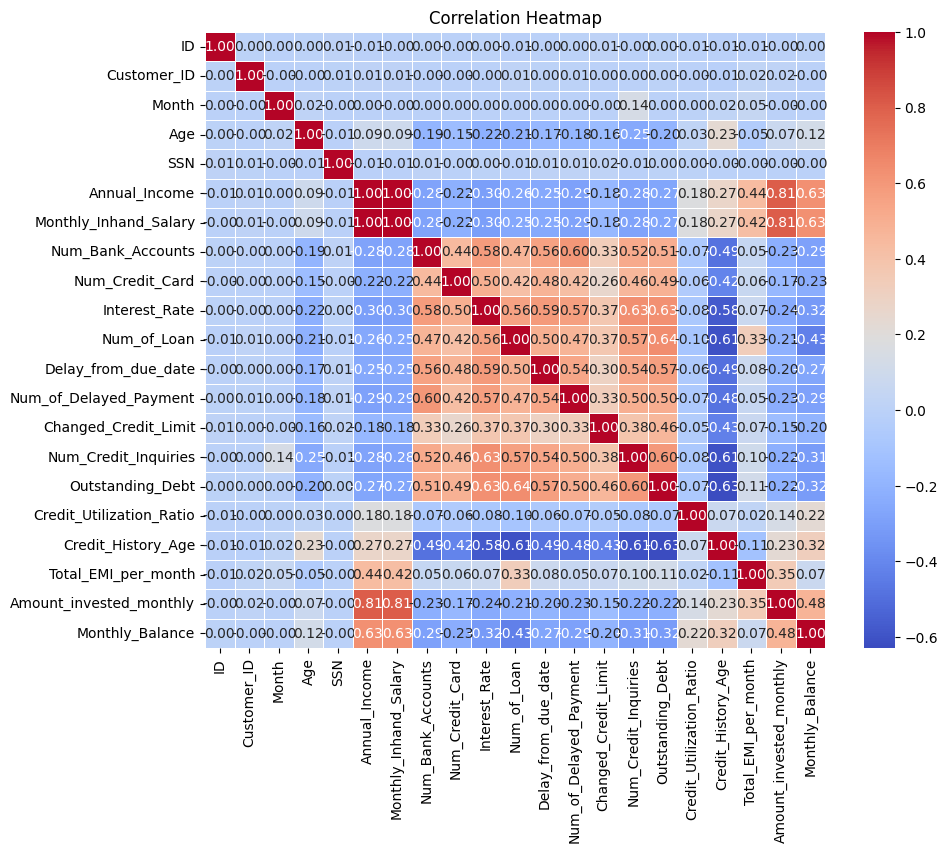

In [14]:
# 다중공산성을 고려하기위해 수치형의 상관계수 확인
corr = data.select_dtypes(include=['number']).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap')
plt.show()

In [15]:
# 고유식별값 컬럼 제거와 시간순서를 나타내는 month 제거. 다중공산성을 문제를 고려해서 상관계수가 높은 컬럼 제거.
# 상관계수 높은 컬럼: 'Monthly_Inhand_Salary' - 'Annual_Income' / 'Amount_invested_monthly' - (Annual_Income, Monthly_Inhand_Salary)
# 이중에서 'Annual_Income', 'Amount_invested_monthly'컬럼 제거를 결정

data = data.drop(columns=['ID', 'Customer_ID', 'Name', 'SSN', 'Month', 'Annual_Income', 'Amount_invested_monthly', 'Type_of_Loan'], axis = 1)

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  int64  
 1   Occupation                100000 non-null  object 
 2   Monthly_Inhand_Salary     100000 non-null  float64
 3   Num_Bank_Accounts         100000 non-null  int64  
 4   Num_Credit_Card           100000 non-null  int64  
 5   Interest_Rate             100000 non-null  int64  
 6   Num_of_Loan               100000 non-null  int64  
 7   Delay_from_due_date       100000 non-null  int64  
 8   Num_of_Delayed_Payment    100000 non-null  int64  
 9   Changed_Credit_Limit      100000 non-null  float64
 10  Num_Credit_Inquiries      100000 non-null  int64  
 11  Credit_Mix                100000 non-null  object 
 12  Outstanding_Debt          100000 non-null  float64
 13  Credit_Utilization_Ratio  100000 non-null  fl

In [17]:
obj_cols = data.select_dtypes(include=['object']).columns.tolist()
num_cols = data.select_dtypes(include=['number']).columns.tolist()
print(obj_cols)
print(num_cols)

['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour', 'Credit_Score']
['Age', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Total_EMI_per_month', 'Monthly_Balance']


In [18]:
for col in obj_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

target_encoder = LabelEncoder()
data['Credit_Score'] = target_encoder.fit_transform(data['Credit_Score'])

In [19]:
X = data.drop('Credit_Score', axis=1)
y = data['Credit_Score']

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 연속형 변 스케일링
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [20]:
# 범주형에 'Credit_Score' 빼기
obj_cols_ny = ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


# 텐서 변형
X_train_obj = torch.tensor(X_train[obj_cols_ny].values, dtype=torch.int64)
X_train_num = torch.tensor(X_train[num_cols].values, dtype=torch.float32)
X_test_obj = torch.tensor(X_test[obj_cols_ny].values, dtype=torch.int64)
X_test_num = torch.tensor(X_test[num_cols].values, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)

In [21]:
!pip install tab-transformer-pytorch

In [22]:
from tab_transformer_pytorch import TabTransformer

In [23]:
# ['Occupation', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']
len(data['Occupation'].unique())


15

In [24]:
# 가지고 있는 데이터는 수치형 + 범주형 데이터이므로 범주형 변수간의 복잡도를 잘 반영하고 분류모델의 최고 성능을 보이는 TabTransformer를 선정
# 100000개의 데이터이기 때문에 batch_size를 설정해 데이터셋을 나눠 학습

In [25]:
from torch.utils.data import DataLoader, TensorDataset

# 데이터셋 및 데이터로더 설정 (배치 사이즈 조절)
batch_size = 256
train_dataset = TensorDataset(X_train_obj, X_train_num, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# 모델 설정
model = TabTransformer(
    categories=(15, 3, 3, 6),
    num_continuous=X_train_num.shape[1],
    dim=32,
    dim_out=3,
    depth=8,
    heads=6,
    attn_dropout=0.1,
    ff_dropout=0.1,
    mlp_hidden_mults=(4, 2),
    mlp_act=nn.ReLU(),
).to(device)

# 손실 함수 및 최적화 도구
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)


y_train_label = y_train_tensor.long().squeeze()
y_test_label = y_test_tensor.long().squeeze()


num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for batch_obj, batch_num, batch_y in train_loader:

        batch_obj = batch_obj.to(device)
        batch_num = batch_num.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()

        outputs = model(batch_obj, batch_num)
        loss = criterion(outputs, batch_y.long())

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Avg Loss: {epoch_loss/len(train_loader):.4f}')

Epoch 5/50, Avg Loss: 0.6784
Epoch 10/50, Avg Loss: 0.6443
Epoch 15/50, Avg Loss: 0.5718
Epoch 20/50, Avg Loss: 0.4584
Epoch 25/50, Avg Loss: 0.3601
Epoch 30/50, Avg Loss: 0.2873
Epoch 35/50, Avg Loss: 0.2347
Epoch 40/50, Avg Loss: 0.1918
Epoch 45/50, Avg Loss: 0.1647
Epoch 50/50, Avg Loss: 0.1449


In [27]:
model.eval()
with torch.no_grad():

    X_test_obj = X_test_obj.to(device)
    X_test_num = X_test_num.to(device)
    y_test_label = y_test_label.to(device)

    test_outputs = model(X_test_obj, X_test_num)
    _, y_pred_class = torch.max(test_outputs, 1)

    accuracy = (y_pred_class == y_test_label).float().mean()
    print(f'---' * 10)
    print(f'Final Valid Accuracy: {accuracy:.4f}')

------------------------------
Final Valid Accuracy: 0.7600


<Figure size 800x600 with 0 Axes>

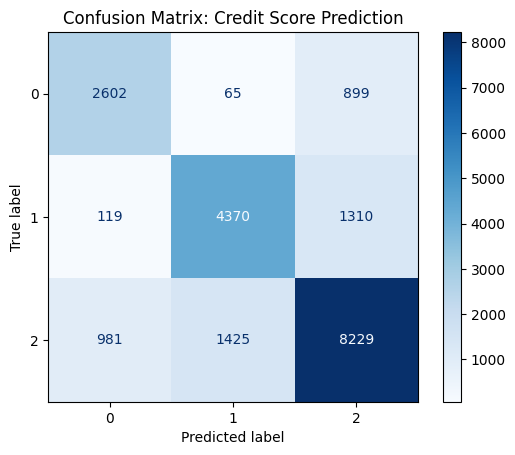

In [28]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_true = y_test_label.cpu().numpy()
y_pred = y_pred_class.cpu().numpy()


cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)

plt.figure(figsize=(8, 6))
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix: Credit Score Prediction')
plt.show()